# Lesson 08a: Theory of NequIP as an E(3)-Equivariant Interatomic Potential

**What you will learn**

- The *atomic energy ansatz*, $E_\mathrm{pot} = \sum_i E_{i,\mathrm{atomic}}$
  and why forces are obtained by autograd.
- The NequIP **interaction block**: convolution filters, $S^{(l)}_m(\vec r_{ij})
  = R(r_{ij})\,Y^{(l)}_m(\hat r_{ij})$, the tensor-product convolution,
  self-interactions, ResNet updates, and the gate nonlinearity.
- How chemistry enters the network: one-hot species embedding and per-species
  energy scale/shift.
- The radial features: trainable **Bessel basis** with a polynomial cutoff
  envelope.
- The empirical result provided by controlled experiments: $l>0$ (equivariant)
  features offer dramatic data efficiency.
- The hyperparameters that define a NequIP model ($l_\text{max}$, channels,
  layers, $r_c$, loss weights).

**Prerequisites**: 

- [Lessons 02b](02b_spherical_harmonics.ipynb): Spherical harmonics,
  [Lesson 03a](03a_tensor_products_theory.ipynb) and [03b](03b_tensor_products_e3nn.ipynb): Tensor products,
  [Lesson 04](04_nonlinearities_and_gates.ipynb): Gates,
  [Lesson 05b](05b_radial_basis_and_cutoffs.ipynb): Radial basis and cutoffs,
  [Lesson 06a](06a_equivariant_convolution.ipynb): Equivariant convolution.

In [1]:
import sys
sys.path.insert(0, "..")    # Make course_utils importable

import matplotlib.pyplot as plt
import numpy as np
import torch
from e3nn import o3
from e3nn.nn import FullyConnectedNet, Gate

from course_utils.data import radius_graph
from course_utils.equivariance import assert_model_equivariant

torch.manual_seed(0)
torch.set_default_dtype(torch.float64)  # Theory notebook: no training, so use float64 throughout
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__} | device: {device}")

torch 2.7.1+cu126 | device: cuda


## The atomic energy ansatz: From positions to energy and forces

NequIP maps the atomic positions, $\{\vec r_i\}$, and chemical species,
$\{Z_i\}$, of a molecule or material to the total potential energy,
$E_\mathrm{pot}$, and the forces, $\{\vec F_i\}$.

Following Behler-Parrinello-style potentials, the total energy of a molecule
with $N_\mathrm{atoms}$ is a **sum of atomic energies** which, in neural
networks, often translates to a scalar value provided by the output node of a
graph neural network (or the output neuron of a dense network):

$$E_\mathrm{pot} \;=\; \sum_{i \,\in\, N_\mathrm{atoms}} E_{i,\mathrm{atomic}}$$

and forces are the **negative gradient of the predicted energy**, computed by automatic differentiation:

$$\vec F_i \;=\; -\nabla_i \, E_\mathrm{pot}$$

Here $\nabla_i$ is the gradient with respect to the position $\vec r_i$ of atom
$i$. This design provides three benefits at once:

1. **Energy conservation:** Because $\vec F = -\nabla E$ by construction, the
   predicted force field is exactly conservative (curl-free) which essential for
   stable and energy-conserving molecular dynamics simulations.

2. **Permutation invariance:** The sum of atomic energies makes the total
   energy, $E_\mathrm{pot}$, invariant under relabeling of identical atoms.

3. **Locality / linear scaling:** Each atomic energy term,
   $E_{i,\mathrm{atomic}}$, depends only on atoms within a cutoff radius $r_c$
   of atom $i$ (propagated over a few message-passing layers). So, the cost of
   evaluation scales linearly with the number of atoms.

## Features are geometric tensors

As discussed in [Lesson 01a](01a_symmetry_and_equivariance.ipynb), a function
$f\colon X \to Y$ is **equivariant** with respect to a group $G$ acting on $X$
and $Y$ if

$$D_Y(g)\, f(x) \;=\; f\big(D_X(g)\, x\big) \qquad \forall g \in G,\; \forall x \in X$$

where $D_X(g)$, $D_Y(g)$ are the representations of $g$ on the two spaces, $X$
and $Y$, respectively. NequIP is equivariant with respect to $E(3)$, which
involves rotations, translations, and reflections.

The core difference from invariant GNN potentials (SchNet, DimeNet — Lesson 07)
is that the **internal node features are geometric tensors**, not just scalars.
The features, $V^{(l,p)}_{acm}$, carry five indices:

| index | meaning |
|---|---|
| $a$ | atom |
| $c$ | channel (which copy of the irrep, i.e. the "feature dimension") |
| $l = 0, 1, 2, \dots$ | rotation order of the $O(3)$ irrep |
| $m \in [-l, l]$ | representation index |
| $p \in \{1, -1\}$ | parity label (even/odd or `e`/`o` in e3nn notation) |

In e3nn, these features can be exactly represented as `o3.Irreps`. For example,
for a NequIP model with $l_\text{max} = 1$ and 32 channels, the features can be
expressed as `32x0e + 32x0o + 32x1o + 32x1e`. Although the final output,
$E_\mathrm{pot}$, is an invariant scalar (`0e`), the hidden states within the
network involve vectors and higher tensors.

## Architecture overview

The NequIP architecture is a stack of three types of blocks:

- **Embedding:** The initial features are generated using a trainable embedding
  that operates on the atomic numbers, $Z_i$, represented via a one-hot
  encoding. The embedding is implemented via a trainable self-interaction layer
  and the outputs are $l=0$ scalars.

- **Interaction blocks:** The convolution layer plus self-interactions, a ResNet
  skip, and a gate nonlinearity. These layers generate $l>0$ features from the
  scalar ($l=0$) embeddings via coupling them with the edge features.

- **Output block:** The $l=0$ features of the final convolution layers are
  passed to an output block, which consists of a set of two atom-wise
  self-interaction layers. The result is a set of scalars values per atom,
  $E_{i,\mathrm{atomic}}$, which are summed to produce the total energy,
  $E_\mathrm{pot}$.

## Chemistry embedding

Chemical species information enters the model in two places:

1. **Input embedding:** The atomic numbers, $Z_i$, are one-hot encoded and
   passed through a trainable *self-interaction* block. The self-interaction
   block is an atom-wise linear layer with weights shared across atoms (the same
   idea used in SchNet's embedding). Since a one-hot vector is a collection of
   scalars, the initial features are pure `0e` irreps: rotating the molecule
   does not change what the atoms are.

2. **Output scale/shift:** The predicted atomic energies are scaled and shifted
   by two learnable **per-species** parameters before the sum:

$$\hat E \;=\; \sum_i \sigma_{s_i}\, \hat E_i + \lambda_{s_i}$$

where $s_i$ denotes the species of atom $i$, $\sigma_{s_i}, \lambda_{s_i}$ are
initialized to 1 and 0 (or to standard deviation and mean calculated from the
dataset). This lets the network spend its capacity on the shape (functional
form) of the potential-energy surface rather than on absolute per-element energy
offsets.

<div style="background: rgba(33, 150, 243, 0.10); border-left: 4px solid #2196f3; padding: 0.6em 1em; margin: 0.8em 0; border-radius: 0 4px 4px 0;"> 

<b>Note:</b> The ResNet skip connection inside each interaction block also uses
<b>per-species weights</b>.
</div>

Let's implement the embedding and output blocks in e3nn.

In [5]:
# A 4-species one-hot embedding, as a trainable self-interaction on 0e scalars.

# Set the number of species in the dataset (e.g. H, C, N, O)
n_species = 4

# Define the irreps for the one-hot encoding and the embedding
# (one-hot entries are invariant scalars)
irreps_onehot = o3.Irreps(f"{n_species}x0e")
irreps_embed = o3.Irreps("16x0e")

# Create a linear layer that maps from the one-hot encoding to the embedding
embedding = o3.Linear(irreps_onehot, irreps_embed)

# Example usage of the embedding layer with a batch of 5 atoms, each represented
# by a species index
Z_row = torch.tensor([0, 2, 2, 1, 3])

# Convert the species indices to one-hot encoding ...
one_hot = torch.nn.functional.one_hot(Z_row, n_species).to(torch.get_default_dtype())

# ... and then pass the one-hot encoding through the embedding layer
h0 = embedding(one_hot)

# Print the shapes of the one-hot encoding and the resulting embedding
print(f"Input one-hot: {tuple(one_hot.shape)}  --Linear({irreps_onehot} -> {irreps_embed})-->  h0: {tuple(h0.shape)}")

Input one-hot: (5, 4)  --Linear(4x0e -> 16x0e)-->  h0: (5, 16)


## The convolution filter: Radial functions × spherical harmonics

Convolutions act on relative positions $\vec r_{ij} = \vec r_j - \vec r_i$ (from central atom $i$ to neighbor $j$ — this sign convention matches the paper and our style guide), which makes them translation invariant. To make them **rotation equivariant**, the filters are constrained (following Tensor Field Networks) to the product of a learnable radial function and spherical harmonics:

$$S^{(l)}_m(\vec r_{ij}) \;=\; R(r_{ij})\; Y^{(l)}_m(\hat r_{ij}) \qquad \text{(Eq. 4)}$$

where $r_{ij} = |\vec r_{ij}|$ and $\hat r_{ij} = \vec r_{ij}/r_{ij}$. **All learnable weights of the filter live in the rotationally invariant radial part** $R(r_{ij})$ — the angular part $Y^{(l)}_m$ is fixed. $R$ is a multi-layer perceptron that outputs, *jointly*, the radial weights for every tensor-product path in the layer:

$$R(r_{ij}) \;=\; W_n\, \sigma\big(\cdots \sigma\big(W_2\, \sigma(W_1\, B(r_{ij}))\big)\big) \qquad \text{(Eq. 5)}$$

with $\sigma = \mathrm{SiLU}$ and $B(r_{ij}) \in \mathbb{R}^{N_b}$ a basis embedding of the distance. NequIP uses **radial Bessel functions with a polynomial envelope** $f_\mathrm{env}$ (the DimeNet cutoff of Klicpera et al. 2020, with $p = 6$):

$$B(r_{ij}) \;=\; \frac{2}{r_c}\,\frac{\sin\!\big(\tfrac{b\pi}{r_c}\, r_{ij}\big)}{r_{ij}} \; f_\mathrm{env}(r_{ij}, r_c) \qquad \text{(Eq. 6)}$$

- $r_c$: cutoff radius; interactions are restricted to $r_{ij} < r_c$.
- $b$: at initialization the Bessel roots are $b = 1, 2, \dots, N_b$; the products $b\pi$ are then **optimized by backpropagation** rather than kept fixed.
- $f_\mathrm{env}$: the polynomial envelope with $p=6$, acting on $x = r_{ij}/r_c$:

$$f_\mathrm{env}(x) \;=\; 1 - \tfrac{(p+1)(p+2)}{2}\,x^{p} + p(p+2)\,x^{p+1}
- \tfrac{p(p+1)}{2}\,x^{p+2}, \qquad x < 1$$

which vanishes at $x=1$ *together with its first two derivatives* — so every filter, and hence the predicted energy, goes **smoothly** to zero as a neighbor crosses the cutoff sphere (Lesson 05b explained why this is non-negotiable for usable forces; Lesson 08b tests it).

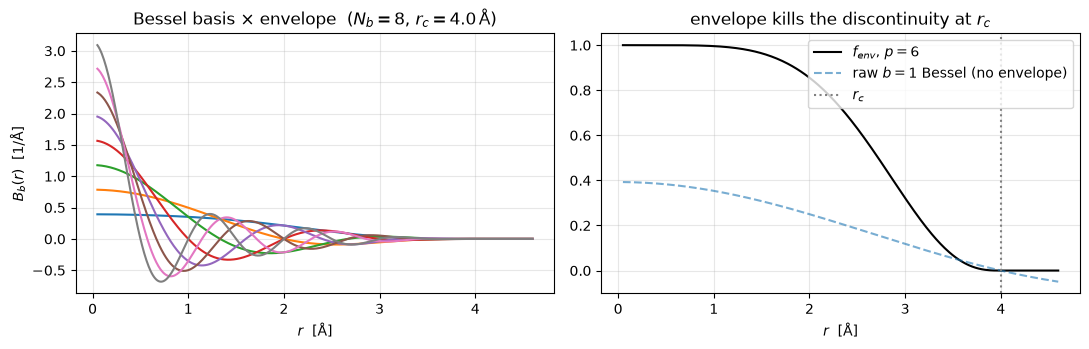

In [4]:
r_c, n_basis, p = 4.0, 8, 6
r = torch.linspace(0.05, 1.15 * r_c, 400)
x = r / r_c
f_env = (1 - (p + 1) * (p + 2) / 2 * x**p + p * (p + 2) * x**(p + 1)
         - p * (p + 1) / 2 * x**(p + 2)) * (x < 1)                      # envelope, p = 6
b = torch.arange(1, n_basis + 1)                                        # Bessel roots (init)
B = (2 / r_c) * torch.sin(b * torch.pi * x[:, None]) / r[:, None]       # Eq. (6), no envelope
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharex=True)
axes[0].plot(r, B * f_env[:, None])
axes[0].set_title(f"Bessel basis $\\times$ envelope  ($N_b={n_basis}$, $r_c={r_c}\\,$Å)")
axes[0].set_ylabel("$B_b(r)$  [1/Å]")
axes[1].plot(r, f_env, "k", label="$f_{env}$, $p=6$")
axes[1].plot(r, B[:, 0], "C0--", alpha=0.6, label="raw $b=1$ Bessel (no envelope)")
axes[1].axvline(r_c, color="gray", ls=":", label="$r_c$")
axes[1].set_title("envelope kills the discontinuity at $r_c$")
axes[1].legend()
for ax in axes:
    ax.set_xlabel("$r$  [Å]"); ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## The tensor-product convolution

The filter $S^{(l_f)}_{m_f}$ and the incoming neighbor feature $V^{(l_i,p_i)}$ must be combined *equivariantly*: NequIP uses the geometric **tensor product**, contracting with Clebsch–Gordan coefficients (Lesson 03). A product of input order $l_i$ with filter order $l_f$ produces outputs of every order

$$|l_i - l_f| \;\le\; l_o \;\le\; l_i + l_f ,$$

truncated at a chosen $l_\text{max}$, with the **parity selection rule**

$$p_o = p_i \, p_f \qquad \text{(Eq. 7)}$$

(spherical harmonics have parity $p_f = (-1)^{l_f}$). The full convolutional layer $\mathcal{L}$ implementing the interaction $l_i \otimes l_f \to l_o$ is (paper, Eq. 8, quoted verbatim up to typography):

$$
\mathcal{L}^{\,l_o,p_o,l_f,p_f,l_i,p_i}_{a c m_o}\big(\vec r_a,\, V^{l_i,p_i}_{a c m_i}\big)
\;=\;
\sum_{m_f, m_i} C^{\,l_o, m_o}_{(l_i, m_i)(l_f, m_f)}
\sum_{b \,\in\, S}
\big(R(r_{ab})\big)_{c,\, l_o p_o l_f p_f l_i p_i}\;
Y^{(l_f)}_{m_f}(\hat r_{ab})\; V^{l_i,p_i}_{b c m_i}
\qquad \text{(Eq. 8)}
$$

Reading guide (the index placement carries no special meaning, per the paper):

- $a$ — central atom; $b \in S$ — its neighbors inside $r_c$; $c$ — channel.
- $C^{\,l_o,m_o}_{(l_i,m_i)(l_f,m_f)}$ — Clebsch–Gordan coefficients (independent of parity).
- $\big(R(r_{ab})\big)_{c,\ldots}$ — the radial MLP of Eq. (5) emits **one weight per channel and per path** $(l_i,p_i) \otimes (l_f,p_f) \to (l_o,p_o)$, evaluated on each edge. In e3nn terms: a `TensorProduct` with `shared_weights=False` whose per-edge weights come from the radial MLP.
- All output tensors with the same $(l_o, p_o)$ arising from different $(l_i, l_f)$ combinations are concatenated (then mixed by a linear self-interaction, next section).
- The sum over neighbors is divided by $\sqrt{\bar N}$, where $\bar N$ is the **average number of neighbors** over the training set — a normalization that keeps feature magnitudes independent of coordination.

Two limits worth internalizing:

- Keep only $0 \otimes 0 \to 0$: the model collapses to a **SchNet-like invariant** GNN — continuous-filter convolutions over scalars.
- Allow $l_\text{max} \ge 1$: messages now carry *directional* information ("neighbor density has a dipole/quadrupole moment in this direction"), which is what unlocks the data efficiency of Section 9.

## Self-interaction, ResNet update, gate

Around the convolution, each interaction block applies (paper, *Network architecture*):

- **Self-interaction**: dense layers applied atom-wise with weights shared across atoms (as in SchNet). They mix *channels* within each $(l, p)$ — "the same set of weights is applied for all representation indices $m$ of a given tensor with rotation order $l$ to maintain equivariance." In e3nn this is exactly `o3.Linear`.
- **ResNet-style update** (He et al. 2016):

$$x^{k+1} \;=\; f(x^k) \;+\; \mathrm{SelfInteraction}(x^k)$$

"where $f$ is the series of self-interaction, convolution, concatenation, and self-interaction. The weights of the Self-Interaction in the preceding formula are learned separately for each species."
- **Gate nonlinearity** (Weiler et al. 2018; Lesson 04): an equivariant, SiLU-based nonlinearity. "Even and odd scalars are not gated, but instead are processed directly by SiLU and tanh nonlinearities, respectively"; each $l>0$ feature is multiplied by an extra nonlinearly activated scalar produced alongside it — a pointwise, norm-preserving-in-direction operation that cannot break equivariance.

## Hands-on: one interaction block in e3nn

We now instantiate a single interaction block and watch the irreps flow through it. (The full model, training, and all verification live in Lesson 08b — here we only want the shapes and the equivariance of one block.)

Toy setting: 5 atoms of one species, scalar input features `8x0e` (as they would come out of the embedding), spherical harmonics up to $l_\text{max} = 2$, and a target feature space `8x0e + 8x0o + 4x1o + 4x1e` for the block output.

In [6]:
# Toy graph: 5 atoms in a box, edges within r_c, edge geometry -> Y and B(r).
r_c, n_basis = 4.0, 8
pos = 2.5 * torch.randn(5, 3)
edge_index = radius_graph(pos, r_c)                       # (2, E): [receiver i, sender j]
recv, send = edge_index
vec = pos[send] - pos[recv]                               # r_ij = r_j - r_i
r_len = vec.norm(dim=-1)

irreps_sh = o3.Irreps.spherical_harmonics(2)              # 1x0e + 1x1o + 1x2e
edge_sh = o3.spherical_harmonics(irreps_sh, vec, normalize=True, normalization="component")

x_b = r_len / r_c
f_env = (1 - 28 * x_b**6 + 48 * x_b**7 - 21 * x_b**8) * (x_b < 1)          # p = 6 envelope
b = torch.arange(1, n_basis + 1)
edge_basis = (2 / r_c) * torch.sin(b * torch.pi * x_b[:, None]) / r_len[:, None] * f_env[:, None]

print(f"{pos.shape[0]} atoms, {edge_index.shape[1]} edges")
print(f"edge_sh    {tuple(edge_sh.shape)}   irreps: {irreps_sh}")
print(f"edge_basis {tuple(edge_basis.shape)}   (N_b = {n_basis} Bessel functions, Eq. 6)")

5 atoms, 6 edges
edge_sh    (6, 9)   irreps: 1x0e+1x1o+1x2e
edge_basis (6, 8)   (N_b = 8 Bessel functions, Eq. 6)


In [7]:
# The gate that will terminate the block: split the target irreps into
# scalars (SiLU / tanh) and gated l>0 features (each gets one extra 0e gate scalar).
irreps_out = o3.Irreps("8x0e + 8x0o + 4x1o + 4x1e")       # what the block should produce
irreps_scalars = o3.Irreps([(m, ir) for m, ir in irreps_out if ir.l == 0])
irreps_gated = o3.Irreps([(m, ir) for m, ir in irreps_out if ir.l > 0])
irreps_gates = o3.Irreps([(m, "0e") for m, _ in irreps_gated])
act = {1: torch.nn.functional.silu, -1: torch.tanh}       # even -> SiLU, odd -> tanh (paper)
gate = Gate(irreps_scalars, [act[ir.p] for _, ir in irreps_scalars],
            irreps_gates, [torch.nn.functional.silu for _ in irreps_gates],
            irreps_gated)
print(f"gate input : {gate.irreps_in}")                   # scalars + gates + gated
print(f"gate output: {gate.irreps_out}")

gate input : 8x0o+16x0e+4x1o+4x1e
gate output: 8x0e+8x0o+4x1o+4x1e


In [8]:
# The weighted tensor product h_j (x) Y(r_ij) -> messages, one 'uvu' path per allowed
# (l_i, p_i) x (l_f, p_f) -> (l_o, p_o) combination [selection rules + Eq. (7)].
irreps_in = o3.Irreps("8x0e")                             # block input (embedding output)
irreps_pre_gate = gate.irreps_in

instructions, irreps_mid = [], []
for i_1, (mul, ir_in) in enumerate(irreps_in):
    for i_2, (_, ir_sh) in enumerate(irreps_sh):
        for ir_o in ir_in * ir_sh:                        # |l1-l2| <= l_o <= l1+l2, p_o = p1 p2
            if ir_o in irreps_pre_gate:
                instructions.append((i_1, i_2, len(irreps_mid), "uvu", True))
                irreps_mid.append((mul, ir_o))
irreps_mid = o3.Irreps(irreps_mid)
irreps_mid, permut, _ = irreps_mid.sort()
instructions = [(i_1, i_2, permut[k], mode, train) for i_1, i_2, k, mode, train in instructions]

tp = o3.TensorProduct(irreps_in, irreps_sh, irreps_mid, instructions,
                      shared_weights=False, internal_weights=False)   # weights come per edge
radial_mlp = FullyConnectedNet([n_basis, 64, 64, 64, tp.weight_numel],
                               torch.nn.functional.silu)              # Eq. (5), 3 hidden layers
print(tp)
print(f"radial MLP output = tp.weight_numel = {tp.weight_numel} weights per edge")

TensorProduct(8x0e x 1x0e+1x1o+1x2e -> 8x0e+8x1o | 16 paths | 16 weights)
radial MLP output = tp.weight_numel = 16 weights per edge


In [9]:
# Assemble the remaining self-interactions and push features through, stage by stage.
lin_pre = o3.Linear(irreps_in, irreps_in)                 # self-interaction before the conv
lin_post = o3.Linear(irreps_mid.simplify(), irreps_pre_gate)
sc = o3.Linear(irreps_in, irreps_pre_gate)                # ResNet skip: SelfInteraction(x^k)
avg_n_neighbors = edge_index.shape[1] / pos.shape[0]

species = torch.zeros(5, dtype=torch.long)                # toy: a single species
embed_8 = o3.Linear(irreps_onehot, irreps_in)             # embedding sized for this block
h = embed_8(torch.nn.functional.one_hot(species, n_species).to(pos.dtype))
print(f"input      h        {tuple(h.shape)}    {irreps_in}")
x = lin_pre(h)
msg = tp(x[send], edge_sh, weight=radial_mlp(edge_basis))            # Eq. (8), per-edge weights
print(f"messages   (edges)  {tuple(msg.shape)}   {irreps_mid.simplify()}")
agg = torch.zeros(pos.shape[0], msg.shape[1]).index_add_(0, recv, msg) / avg_n_neighbors**0.5
print(f"aggregated (atoms)  {tuple(agg.shape)}   (sum over neighbors / sqrt(N))")
y = lin_post(agg) + sc(h)                                             # ResNet update
print(f"pre-gate            {tuple(y.shape)}   {irreps_pre_gate}")
out = gate(y)
print(f"output     x^(k+1)  {tuple(out.shape)}   {gate.irreps_out}")
# Note: with pure-scalar (0e) input, layer 1 can only populate 0e (0e⊗0e), 1o (0e⊗1o) and
# 2e (0e⊗2e) — the 0o/1e slots stay zero until layer 2 couples l>0 features to each other.

input      h        (5, 8)    8x0e
messages   (edges)  (6, 32)   8x0e+8x1o
aggregated (atoms)  (5, 32)   (sum over neighbors / sqrt(N))
pre-gate            (5, 48)   8x0o+16x0e+4x1o+4x1e
output     x^(k+1)  (5, 40)   8x0e+8x0o+4x1o+4x1e


### Equivariance check

We wrap the whole block as a function of the atomic positions (the fixed scalar features cannot break symmetry) and test it against random rotations, inversions, and translations with the shared course harness. Output irreps: the gate's output.

In [10]:
def block_on_positions(pos):
    edge_index = radius_graph(pos, r_c)
    recv, send = edge_index
    vec = pos[send] - pos[recv]
    r_len = vec.norm(dim=-1)
    edge_sh = o3.spherical_harmonics(irreps_sh, vec, normalize=True, normalization="component")
    x_b = r_len / r_c
    f_env = (1 - 28 * x_b**6 + 48 * x_b**7 - 21 * x_b**8) * (x_b < 1)
    edge_basis = (2 / r_c) * torch.sin(b * torch.pi * x_b[:, None]) / r_len[:, None] * f_env[:, None]
    x = lin_pre(h)
    msg = tp(x[send], edge_sh, weight=radial_mlp(edge_basis))
    agg = torch.zeros(pos.shape[0], msg.shape[1]).index_add_(0, recv, msg) / avg_n_neighbors**0.5
    return gate(lin_post(agg) + sc(h))

assert_model_equivariant(block_on_positions, pos, gate.irreps_out, tol=1e-9)

equivariant ✓  (max error 4.441e-16 over random E(3) elements)


4.440892098500626e-16

## Forces by autograd = energy conservation for free

NequIP never *predicts* forces with a separate head. It differentiates the energy (Eq. 3) with `torch.autograd.grad(E, pos)`. Consequences:

- The force field is **exactly conservative**: $\vec F = -\nabla E$ implies $\oint \vec F \cdot d\vec l = 0$ on any closed path, so MD with a symplectic integrator conserves energy up to integration error (no systematic drift from the model itself).
- **Force equivariance is inherited**: if $E$ is invariant, its gradient automatically transforms as a vector, $\vec F_i(R\,\vec r + t) = R\, \vec F_i(\vec r)$ — nothing extra to enforce. (Under inversion the positions flip sign and so do the forces: forces are *odd* vectors, `1o`.)
- Each training structure supplies $3N$ force labels in addition to 1 energy label — a total of $M(3N+1)$ labels from $M$ reference calculations. Training on forces is where most of the supervision comes from, which is reflected in the loss weighting of Lesson 08b (paper Eq. 9).

## Why $l>0$ features buy data efficiency

The headline empirical result of the paper: NequIP reaches state-of-the-art accuracy with **hundreds to a few thousand** reference calculations, where earlier deep models used $10^5$–$10^6$ (e.g., on liquid water it outperforms DeepMD trained on <0.1% as much data — paper Table 3).

On MD-17 (1000 training configurations), force MAE on **aspirin** [meV/Å], from paper Table 1:

| SchNet | DimeNet | sGDML | PaiNN | SpookyNet | GemNet-(T/Q) | **NequIP** ($l=3$) |
|---|---|---|---|---|---|---|
| 58.5 | 21.6 | 29.5 | 14.7 | 11.2 | 9.4 | **8.0** |

**Is it really the equivariance?** The paper isolates the effect (*Data efficiency* section) by training networks with identical hyperparameters but interactions switched between full tensor features ($l \in \{1,2,3\}$) and scalars only ($l=0$, i.e. an invariant SchNet-style model), on bulk-water data:

- Equivariant networks ($l \ge 1$) **outperform the invariant one at every training-set size** (paper Fig. 5).
- Learning curves typically follow a power law $\epsilon \propto a N^{b}$ whose exponent $b$ (log–log slope) was believed fixed for a given data set, with methods differing only in the offset $a$. The equivariant networks show a **different, steeper log–log slope** than the invariant version — equivariance changes *how fast* the model learns from new data, not just where it starts.
- **Controls**: weight-controlled ($l=0$ network widened to match the $l=1$ parameter count) and feature-controlled ($l=0$ with 4× features, matching `64x0o + 64x0e + 64x1o + 64x1e`) versions show qualitatively the same gap — so it is not about parameter count.
- Against a Behler–Parrinello NN trained on 1303 water structures (force RMSE ≈ 120 meV/Å), NequIP ($l=2$) reaches 123.3 meV/Å with **100** structures and 98.3 meV/Å with **250**.

The intuition: an $l=0$ model must *reconstruct* angular information indirectly through overlaps of many radial filters across layers; an equivariant model transports it natively — each message already says "the neighbor density around me points *this way*" with dipole ($l=1$), quadrupole ($l=2$), ... resolution, and tensor products let those geometric moments interfere coherently.

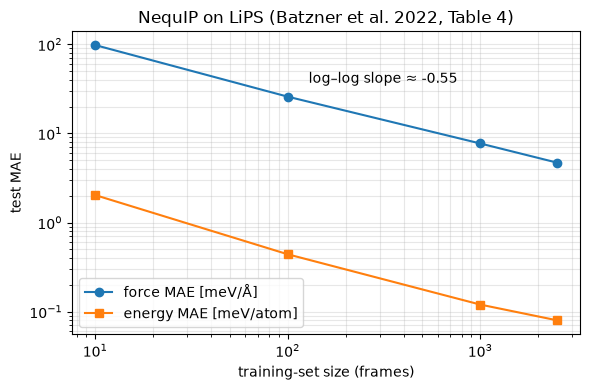

In [11]:
# Data efficiency in practice: NequIP force/energy MAE vs training-set size on LiPS
# (values transcribed from Batzner et al. 2022, Table 4).
sizes = np.array([10, 100, 1000, 2500])
f_mae = np.array([97.8, 25.8, 7.7, 4.7])        # meV/Å
e_mae = np.array([2.03, 0.44, 0.12, 0.08])      # meV/atom
fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(sizes, f_mae, "o-", label="force MAE [meV/Å]")
ax.loglog(sizes, e_mae, "s-", label="energy MAE [meV/atom]")
slope = np.polyfit(np.log(sizes), np.log(f_mae), 1)[0]
ax.annotate(f"log–log slope ≈ {slope:.2f}", (sizes[1], f_mae[1]), textcoords="offset points",
            xytext=(15, 10))
ax.set_xlabel("training-set size (frames)")
ax.set_ylabel("test MAE")
ax.set_title("NequIP on LiPS (Batzner et al. 2022, Table 4)")
ax.grid(True, which="both", alpha=0.3); ax.legend()
fig.tight_layout()
plt.show()

## Architecture hyperparameters

From paper Table 5 and *Methods*. "# features" means channels *per irrep*, with even and odd copies: e.g. $l_\text{max}=1$ with 32 features $\Rightarrow$ `32x0o + 32x0e + 32x1o + 32x1e`.

| Data set | $l_\text{max}$ | # features | $r_c$ [Å] | $\lambda_E$ | $\lambda_F$ |
|---|---|---|---|---|---|
| MD-17 | 3 | 64 | 4.0 | 1 | 1000 |
| revMD-17 | {0, 1, 2, 3} | 64 | 4.0 | 1 | 1000 |
| CCSD/CCSD(T) molecules | 3 | 64 | 4.0 | 1 | 1000 |
| Water + ices (DeepMD ref.) | 2 | 32 | 6.0 | (Table 3) | (Table 3) |
| Formate on Cu | 2 | 32 | 5.0 | 1 | 2704 |
| Li$_4$P$_2$O$_7$ | 2 | 32 | 5.0 | 1 | 43 264 |
| LiPS | 2 | 32 | 5.0 | 1 | 6889 |
| Water (Cheng et al.) | {0, 1, 2, 3} | 32 | 4.5 | 1 | 36 864 |

Other defaults (paper *Methods*):

- **Layers**: 5 interaction blocks (molecules) / 6 (periodic systems); depth is *not* a sensitive hyperparameter "as long as set within a reasonable range".
- **Radial MLP**: Bessel basis of size $N_b = 8$; three hidden layers of 64 neurons, SiLU.
- **Output block**: self-interaction to 16 even scalars, then to a single scalar per atom.
- **Optimizer**: Adam (AMSGrad), lr 0.01 / batch 5 (molecules), lr 0.005 / batch 1 (periodic); small batch sizes matter. LR ×0.8 on validation plateau; EMA of weights (decay 0.99) for evaluation.
- **Loss weights**: $\lambda_E = 1$, $\lambda_F \approx N_\mathrm{atoms}^2$ is a good default (note $2704 = 52^2$, $6889 = 83^2$ in the table).
- $r_c$ *does* matter and should be chosen per system.

## Summary

- NequIP predicts a **sum of atomic energies** (Eq. 2) and gets forces from **autograd** (Eq. 3) — conservative by construction.
- The interaction block = self-interaction → **tensor-product convolution** with filters $S^{(l)}_m = R(r)\, Y^{(l)}_m(\hat r)$ (Eqs. 4, 8) → concatenate + self-interaction → ResNet skip → **gate** nonlinearity. All learnable filter weights sit in the radial MLP (Eq. 5) on a trainable **Bessel × polynomial-envelope** basis (Eq. 6).
- Parity and rotation-order selection rules (Eq. 7 and $|l_i-l_f| \le l_o \le l_i+l_f$) define which tensor-product paths exist; truncation at $l_\text{max} = 0$ recovers an invariant SchNet-like model.
- $l>0$ features are the source of NequIP's **data efficiency**: better accuracy at every training-set size *and* a steeper learning-curve slope, robust to parameter-count controls.
- We instantiated one interaction block, traced the irreps through it, and verified its E(3)-equivariance numerically.

**Next**: Lesson 08b assembles these blocks into a complete `SimpleNequIP`, verifies energy invariance / force covariance / cutoff smoothness, and trains it on Lennard-Jones argon.

## Exercises

**1.** With input irreps `8x0e + 8x1o` and filter irreps `1x0e + 1x1o + 1x2e` ($l_\text{max} = 2$), list every allowed output irrep $(l_o, p_o)$ with its multiplicity, applying both selection rules. Which outputs would an invariant model ($l_\text{max} = 0$) retain?

<details><summary>Solution</summary>

From `0e` inputs: $0e\otimes 0e \to 0e$, $0e \otimes 1o \to 1o$, $0e \otimes 2e \to 2e$ (8 each). From `1o` inputs: $1o \otimes 0e \to 1o$; $1o \otimes 1o \to 0e, 1e, 2e$; $1o \otimes 2e \to 1o, 2o, 3o$ (8 each; $3o$ dropped if $l_\text{max}=2$). Total (with $l_\text{max} = 2$): $16\times 0e$, $24 \times 1o$, $8 \times 1e$, $16 \times 2e$, $8\times 2o$. An invariant model keeps only $0e \otimes 0e \to 0e$: `8x0e`. Note every parity obeys $p_o = p_i p_f$ with $p_f = (-1)^{l_f}$ for spherical harmonics. </details>

**2.** The envelope $f_\mathrm{env}$ with $p=6$ satisfies $f(1)=f'(1)=f''(1)=0$. Verify the $f'(1)=0$ claim analytically from the polynomial in Section 5, and explain why smoothness of $E(r)$ *at the cutoff* matters for MD even though the model is trained only on configurations with all kinds of interatomic distances.

<details><summary>Solution</summary>

$f(x) = 1 - 28x^6 + 48x^7 - 21x^8 \Rightarrow f'(x) = -168x^5 + 336x^6 - 168x^7$, so $f'(1) = -168 + 336 - 168 = 0$ (and $f''(1) = -840 + 2016 - 1176 = 0$). During MD, atoms continuously *cross* the cutoff sphere. If the filter jumped at $r_c$, the energy would be discontinuous and the force would contain a delta-like spike each crossing — heating the system and destroying energy conservation regardless of how well the model fits the training set. </details>

**3.** In Eq. (8), why must the radial weights $R(r_{ab})$ be *scalars* per path/channel rather than, say, functions of the full vector $\vec r_{ab}$? What would break if the weights depended on $\hat r_{ab}$ directly?

<details><summary>Solution</summary>

The filter must transform as an irrep of $O(3)$. Factorizing $S = R(r)\, Y^{(l)}_m(\hat r)$ puts *all* angular dependence into $Y^{(l)}_m$, whose transformation under rotation is exactly the Wigner matrix $D^{(l)}$ — that is what makes the CG contraction in Eq. (8) equivariant. $r_{ab}$ is invariant, so any learnable function of it is safe. If weights depended on $\hat r_{ab}$ in an unconstrained way, the filter would no longer transform as $D^{(l)}$, the CG algebra would not close, and equivariance (and with it the exact force covariance of Section 9) would be lost. </details>

## References

Batzner et al., *E(3)-equivariant graph neural networks for data-efficient and accurate interatomic potentials* (Nat. Commun. **13**, 2453, 2022) — [Batzner Nat. Commun. 13 2453 2022](https://doi.org/10.1038/s41467-022-29939-5). All equation numbers below refer to this paper. Secondary: Thomas et al., *Tensor Field Networks* (2018) — [Thomas arXiv 1802.08219 2018](https://arxiv.org/pdf/1802.08219); Geiger & Smidt, *e3nn* (2022) — [Geiger arXiv 2207.09453 2022](https://arxiv.org/pdf/2207.09453).

*This is the theory half; Lesson 08b builds and trains the model block-by-block.*